In [28]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import os

In [29]:
os.environ["PATH"] = "/vast/palmer/apps/avx2/software/texlive/20220321-GCC-12.2.0/bin/x86_64-linux:" + os.environ["PATH"]
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{lmodern}",
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6,
    "figure.figsize": [10, 7],
    "svg.fonttype": "none",
    "image.cmap": "viridis",
})

In [30]:
THOMSON_DATA_DIR = Path("/home/rg2248/project/friction/data/local-friction/thomson/sample")
UNIFORM_DATA_DIR = Path("/home/rg2248/project/friction/data/local-friction/uniform/sample")

In [31]:
def load_data(data_dir):
    files = sorted(
        data_dir.glob("mu-*.npz"),
        key=lambda path: float(path.stem.removeprefix("mu-")),
    )

    return {
        float(path.stem.removeprefix("mu-")): dict(np.load(path))
        for path in files
    }

thomson_data = load_data(THOMSON_DATA_DIR)
uniform_data = load_data(UNIFORM_DATA_DIR)

mu_eff = np.array(sorted(thomson_data.keys() & uniform_data.keys()))
data = thomson_data
jammed_data = thomson_data

In [32]:
for value in mu_eff:
    jammed = jammed_data[value]

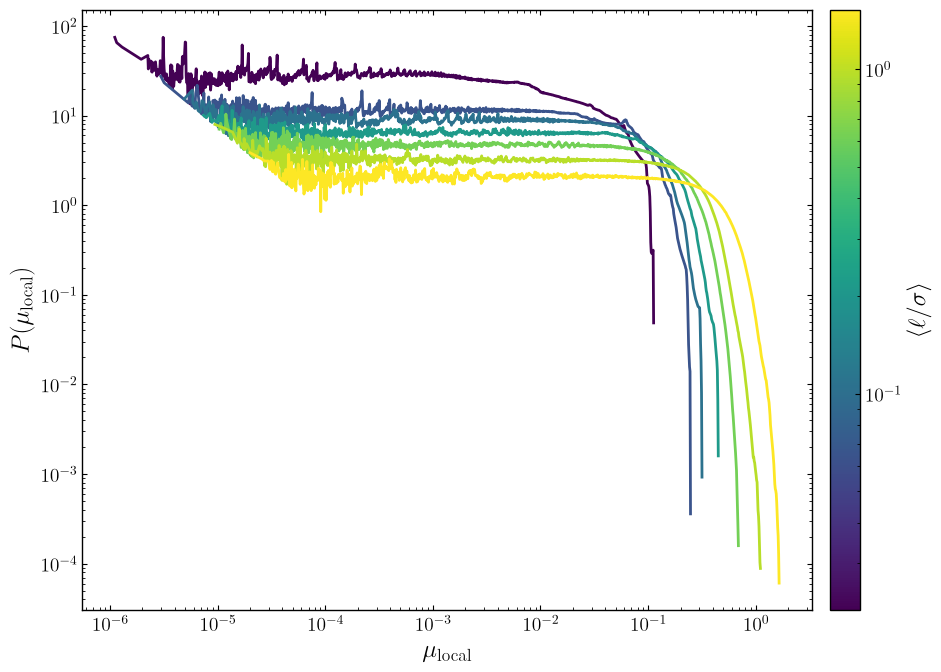

In [33]:
from matplotlib.colors import LogNorm

l_over_sigma = np.array([
    float(jammed_data[value]["l_over_sigma"])
    if "l_over_sigma" in jammed_data[value]
    else 2 * value / np.sqrt(1 + value**2)
    for value in mu_eff
])
min_count = 10

def positive(values):
    return values[np.isfinite(values) & (values > 0)]

positive_values = np.concatenate([
    positive(jammed_data[value]["mu"])
    for value in mu_eff
])

bins = np.logspace(
    np.log10(positive_values.min()),
    np.log10(positive_values.max()),
    2000,
)

centers = np.sqrt(bins[:-1] * bins[1:])
norm = LogNorm(l_over_sigma.min(), l_over_sigma.max())
cmap = plt.get_cmap("viridis")

def density(values):
    values = positive(values)
    counts, _ = np.histogram(values, bins=bins)
    probability = counts / (len(values) * np.diff(bins))
    return probability, counts

fig, ax = plt.subplots()

for value, ratio in zip(mu_eff, l_over_sigma):
    probability, counts = density(jammed_data[value]["mu"])
    mask = counts >= min_count

    ax.plot(
        centers[mask],
        probability[mask],
        color=cmap(norm(ratio)),
    )

colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax,
    pad=0.02,
)

colorbar.set_label(r"$\langle \ell/\sigma \rangle$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\mu_{\mathrm{local}}$")
ax.set_ylabel(r"$P(\mu_{\mathrm{local}})$")
plt.tight_layout()
plt.savefig("../../figures/friction/thomson/single_particle-distributions.png", dpi=600, bbox_inches="tight")
plt.show()

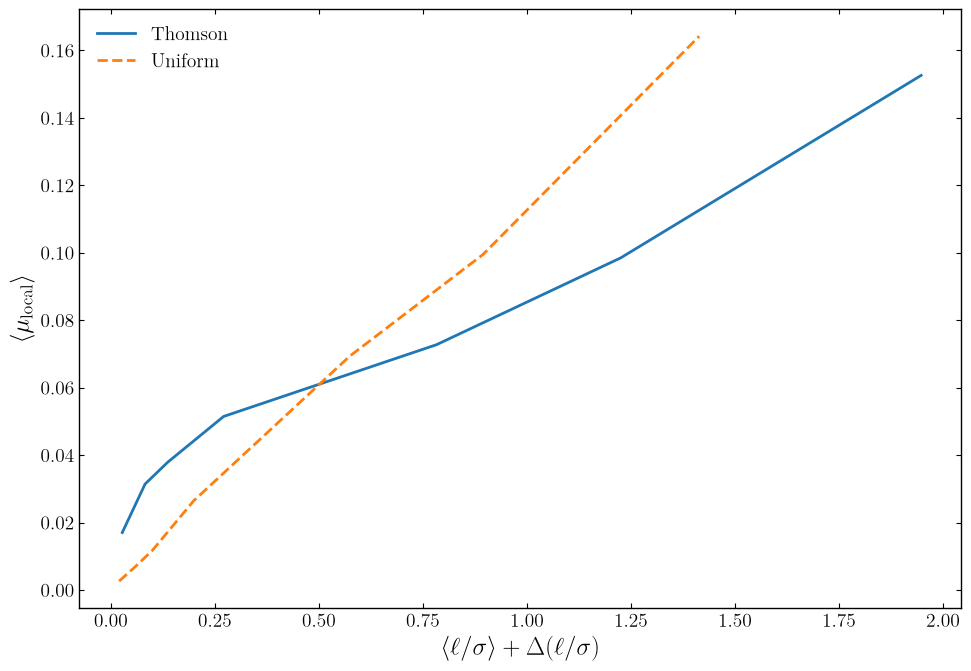

In [39]:
def edge_l_over_sigma_std(record):
    if "l_over_sigma_std" in record:
        return float(record["l_over_sigma_std"])
    if "edge_l_over_sigma" in record:
        return float(np.std(record["edge_l_over_sigma"]))
    return 0.0

thomson_mean = np.array([
    float(thomson_data[value]["l_over_sigma"])
    for value in mu_eff
])
thomson_std = np.array([
    edge_l_over_sigma_std(thomson_data[value])
    for value in mu_eff
])
thomson_y = np.array([
    thomson_data[value]["mu"].mean()
    for value in mu_eff
])

uniform_mean = 2 * mu_eff / np.sqrt(1 + mu_eff**2)
uniform_std = np.array([
    edge_l_over_sigma_std(uniform_data[value])
    for value in mu_eff
])
uniform_y = np.array([
    uniform_data[value]["ss"].mean()
    for value in mu_eff
])

x_thomson = thomson_mean + thomson_std
x_uniform = uniform_mean + uniform_std

order = np.argsort(x_thomson)
x_thomson = x_thomson[order]
y_thomson = thomson_y[order]

order_uniform = np.argsort(x_uniform)
x_uniform = x_uniform[order_uniform]
y_uniform = uniform_y[order_uniform]

fig, ax = plt.subplots()

ax.plot(
    x_thomson,
    y_thomson,
    color="C0",
    marker=None,
    linestyle="-",
    label="Thomson",
)

ax.plot(
    x_uniform,
    y_uniform,
    color="C1",
    marker=None,
    linestyle="--",
    label="Uniform",
)

ax.set_xlabel(r"$\langle \ell/\sigma \rangle + \Delta(\ell/\sigma)$")
ax.set_ylabel(r"$\langle\mu_{\mathrm{local}}\rangle$")
# ax.set_xscale("log")
# ax.set_yscale("log")
ax.legend(frameon=False)
plt.tight_layout()
# plt.savefig("../../figures/friction/thomson/mean-mu.png", dpi=600, bbox_inches="tight")
plt.show()